## SimpleCNN Model v1

### Data Preparation & Loading

This section handles the preprocessing pipeline and data loading for the Brain MRI dataset. The image processing includes:  
* Resizing all brain MRI scans to a $256 \times 256$ resolution and converting them into PyTorch tensors.
* Organizing images into `Training` and `Testing` sets using `ImageFolder` (mapping subdirectories to class labels).
* Creates data streams (`DataLoaders`) that shuffle the training data to prevent ordering bias and process images in batches of 32.

In [1]:
import torch
from torchvision import datasets, transforms

# basic transform to make all images 256x256 and convert to Tensors
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
    ])

# load train and test dataset paths
train_path = 'brain_mri_dataset/Training/' 
test_path = 'brain_mri_dataset/Testing/'

# load train/test datasets and subfolder names
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# image data loading in batches
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

print('Data Loaded Successfully...')

Data Loaded Successfully...


### Model Architecture: SimpleCNN

This section defines a custom CNN for classifying 4 distinct categories in the brain MRI dataset. The model includes:

Feature Extraction (convolutional layers):
* Conv1: Accepts an RGB image (3 channels) and extracts 16 features. Max pooling halves the spatial resolution from $256 \times 256 \rightarrow 128 \times 128$.
* Conv2: Expands feature maps from 16 to 32. Max pooling halves the size from $128 \times 128 \rightarrow 64 \times 64$.
* Conv3: Expands feature maps from 32 to 64. Max pooling halves the final size from $64 \times 64 \rightarrow 32 \times 32$.  

Classification (fully connected layers):
  * Flatten Layer: Flattens the 3D feature maps into a 1D vector. 
  * Linear 1: Maps features down to 256 dense representations with a ReLU activation function.
  * Linear 2 (Output): Outputs raw logits for the 4 target classification categories.

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # cut image size by half
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)  # input size: 256x256
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1) # input size: 128x128
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # input size: 64x64

        self.full_conn1 = nn.Linear(in_features=64 * 32 * 32, out_features=256)  # input size: 32x32
        self.full_conn2 = nn.Linear(in_features=256, out_features=4)  # output size: 4 classes 
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # output size: 128x128
        x = self.pool(F.relu(self.conv2(x)))  # output size: 64x64
        x = self.pool(F.relu(self.conv3(x)))  # output size: 32x32

        x = torch.flatten(x, start_dim=1)  # flatten the tensor for fully connected layer
        x = F.relu(self.full_conn1(x))
        x = self.full_conn2(x)
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (full_conn1): Linear(in_features=65536, out_features=256, bias=True)
  (full_conn2): Linear(in_features=256, out_features=4, bias=True)
)


### Model Training & Evaluation Loop

This section initializes the training configurations and executes the training loop over a set number of epochs.

Environment & Hyperparameters: 
* Defaults to the CPU for computing.
* Loss Function uses `CrossEntropyLoss`, which is good for multi-class classification problems.
* Implements the **Adam** optimizer with a learning rate (`lr`) of `0.001` to adjust model weights.
* Epochs are set to run for `5` passes through the entire dataset.

Training Pipeline (per run):

The loop cycles between two distinct phases to optimize and evaluate performance:

| | Key Operations | Purpose |
| :--- | :--- | :--- 
| Training | `model.train()` <br> `optimizer.zero_grad()` <br> `loss.backward()` <br> `optimizer.step()` | Sets layers to training mode, computes predictions, calculates error gradients, and updates model weights via backpropagation. |
| Evaluation | `model.eval()` <br> `torch.no_grad()` | Disables gradient calculations and dropout layers to evaluate model generalization on the unseen test dataset efficiently. |

In [3]:
import torch.optim as optim

device = torch.device("cpu")
print(f"Using device: {device}")

# move the model to the chosen device (cpu)
model = model.to(device)

# define loss function (criterion) and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# set num of epochs (passes through the dataset)
epochs = 5

# init lists to track history of stats
train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    # ------ TRAINING PHASE ------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        # move data to the same device as model
        images, labels = images.to(device), labels.to(device)
        
        # reset/zero out the parameter gradients
        optimizer.zero_grad()
        
        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # track training stats (error and accuracy)
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)  # _ represents the max logit value; we only care about predicted index value of logit
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # track total training stats per epoch
    epoch_loss = running_loss / total_train
    epoch_acc = (correct_train / total_train) * 100
    
    # -------- TESTING PHASE --------
    model.eval()
    correct_test = 0
    total_test = 0
    
    with torch.no_grad(): # disable gradient calculation for efficiency, since no longer needed because not in training phase
        # forward pass
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # track testing stats (accuracy)
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    # track total testing accuracy per epoch
    test_acc = (correct_test / total_test) * 100

    # save epoch stats to history lists
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    test_accuracies.append(test_acc)
    
    # print stats for each epoch, kept to 4 decimal places
    print(f"Epoch {epoch+1}/{epochs} "
          f"| Train Loss: {epoch_loss:.4f} "
          f"| Train Acc: {epoch_acc:.4f}% "
          f"| Test Acc: {test_acc:.4f}%")

print("Training finished!")

Using device: cpu
Epoch 1/5 | Train Loss: 0.6337 | Train Acc: 74.7143% | Test Acc: 77.2500%
Epoch 2/5 | Train Loss: 0.3274 | Train Acc: 87.6429% | Test Acc: 84.3125%
Epoch 3/5 | Train Loss: 0.1661 | Train Acc: 93.8036% | Test Acc: 81.8125%
Epoch 4/5 | Train Loss: 0.0928 | Train Acc: 96.9643% | Test Acc: 85.9375%
Epoch 5/5 | Train Loss: 0.0391 | Train Acc: 98.7143% | Test Acc: 84.6250%
Training finished!


### Performance Visualization

This section plots the training loss and accuracy progress over all epochs. The graphs include:  

* Tracking how well the model is minimizing its error.
* Comparing the training accuracy and testing accuracy. 

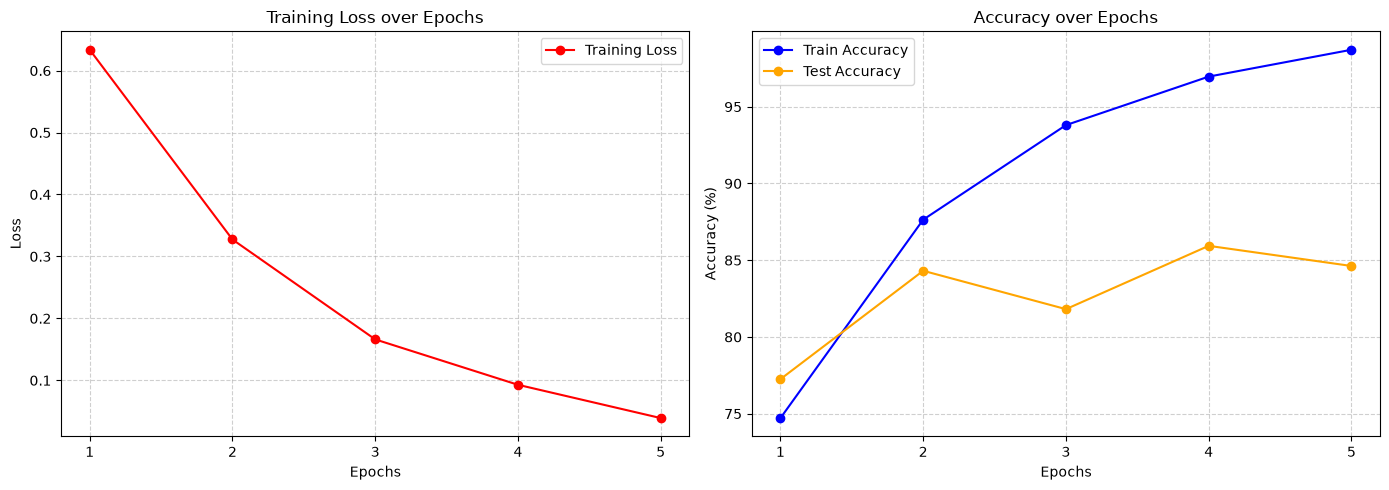

In [4]:
import matplotlib.pyplot as plt
epochs_range = range(1, epochs + 1)

# create a layout for plots
fig, (plot1, plot2) = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: training Loss
plot1.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o')
plot1.set_title('Training Loss over Epochs')
plot1.set_xlabel('Epochs')
plot1.set_ylabel('Loss')
plot1.set_xticks(epochs_range)  # integer steps on the x axis
plot1.grid(True, linestyle='--', alpha=0.6)
plot1.legend()

# plot 2: training and testing accuracy
plot2.plot(epochs_range, train_accuracies, label='Train Accuracy', color='blue', marker='o')
plot2.plot(epochs_range, test_accuracies, label='Test Accuracy', color='orange', marker='o')
plot2.set_title('Accuracy over Epochs')
plot2.set_xlabel('Epochs')
plot2.set_ylabel('Accuracy (%)')
plot2.set_xticks(epochs_range)
plot2.grid(True, linestyle='--', alpha=0.6)
plot2.legend()

plt.tight_layout()
plt.show()